In [1]:
import pandas as pd
import csv
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



# Training 0004

In [2]:
def load_data(v):
    with open(f'mutation_dataset_10-06_v{v}\\simulacoes_com_erro.pkl', 'rb') as arquivo:
        simulacoes_com_erro = pickle.load(arquivo)

    trees_cblv = np.load(f'mutation_dataset_10-06_v{v}\\tree_data.npy')
    trees_cblv = np.delete(trees_cblv, simulacoes_com_erro, axis=0)

    #R_0_1, infectuos time and a taxa relativa 
    # Retornando a segunda coluna (coluna referente ao R_nought)
    # e em segunda transformando a lista em um np.array

    tabela_de_parametros = np.load(f'mutation_dataset_10-06_v{v}\\tabela_parametros.npy')
    tabela_de_parametros = np.delete(tabela_de_parametros, simulacoes_com_erro, axis=0)

    R_nought1 = np.array([sublist[0] for sublist in tabela_de_parametros])
    R_nought2 = np.array([sublist[1] for sublist in tabela_de_parametros])
    infectious_time = np.array([sublist[8] for sublist in tabela_de_parametros])
    proportion_tr11_tr22 = np.array([sublist[10] for sublist in tabela_de_parametros])
    
    rescale_factors = np.load(f'mutation_dataset_10-06_v{v}\\rescale_factor.npy')
    rescale_factors = np.delete(rescale_factors, simulacoes_com_erro)

    infectious_time_div_reascale = np.round(infectious_time / rescale_factors, 3)

    mutation_masks = np.load(f'mutation_dataset_10-06_v{v}\\mutation_masks.npy')
    mutation_masks = np.delete(mutation_masks, simulacoes_com_erro, axis=0)

    vectorized = np.column_stack((R_nought1, R_nought2, infectious_time_div_reascale))

    masked = np.multiply(trees_cblv, mutation_masks)
    trees_cblv_and_masked = np.column_stack((trees_cblv, masked))

    return trees_cblv, mutation_masks, rescale_factors

In [3]:
X, y, rescale_factors = load_data(0)

In [4]:
print(X.shape)
print(y.shape)

(99994, 1002)
(99994, 1002)


In [5]:
test_size = 10000
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    shuffle=False
)

In [6]:
y_train = y_train.reshape(-1, 501, 2)
y_test  = y_test.reshape(-1, 501, 2)

In [7]:
modelo = tf.keras.models.Sequential([
    layers.Input(X_train[0].shape),
    layers.Reshape((501, 2)),
    layers.Conv1D(filters = 50, kernel_size = 3, activation='relu', padding='same'),
    layers.Conv1D(filters = 50, kernel_size = 10, activation='relu', padding='same'),
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    layers.Conv1D(filters=2, kernel_size=1, activation='sigmoid', padding='same', name='mask')
    ])

modelo.compile(optimizer='adam',loss='binary_crossentropy',
               metrics=['binary_crossentropy',
                        tf.keras.metrics.BinaryAccuracy(),
                        tf.keras.metrics.Precision(),
                        tf.keras.metrics.Recall()])
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 501, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 501, 50)        │           350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 501, 50)        │        25,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 501, 32)        │         4,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mask (Conv1D)                   │ (None, 501, 2)         │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,298 (118.35 KB)

 Trainable params: 30,298 (118.35 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(monitor='val_binary_crossentropy', mode='min', patience=25, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_binary_crossentropy', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

In [9]:
history = modelo.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.1, callbacks=[early_stop, reduce_lr])

Epoch 1/200
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 122s 47ms/step - binary_accuracy: 0.7967 - binary_crossentropy: 0.4378 - loss: 0.4378 - precision: 0.7573 - recall: 0.5005 - val_binary_accuracy: 0.8333 - val_binary_crossentropy: 0.3840 - val_loss: 0.3840 - val_precision: 0.8884 - val_recall: 0.5322 - learning_rate: 0.0010
Epoch 2/200
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 118s 47ms/step - binary_accuracy: 0.8401 - binary_crossentropy: 0.3650 - loss: 0.3650 - precision: 0.8028 - recall: 0.6538 - val_binary_accuracy: 0.8383 - val_binary_crossentropy: 0.3675 - val_loss: 0.3675 - val_precision: 0.7436 - val_recall: 0.7347 - learning_rate: 0.0010
Epoch 3/200
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 125s 49ms/step - binary_accuracy: 0.8441 - binary_crossentropy: 0.3568 - loss: 0.3568 - precision: 0.8044 - recall: 0.6620 - val_binary_accuracy: 0.8461 - val_binary_crossentropy: 0.3519 - val_loss: 0.3519 - val_precision: 0.7986 - val_recall: 0.6771 - learning_rate: 0.0010
Epoch 4/200
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 125

In [13]:
path = "modelos\\0004"

modelo.save(path + "\\modelo.keras")

#with open(path + "\\scaler.pkl", "wb") as f:
#    pickle.dump(scaler, f)

with open(path + "\\history.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [10]:
pred_mask = modelo.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


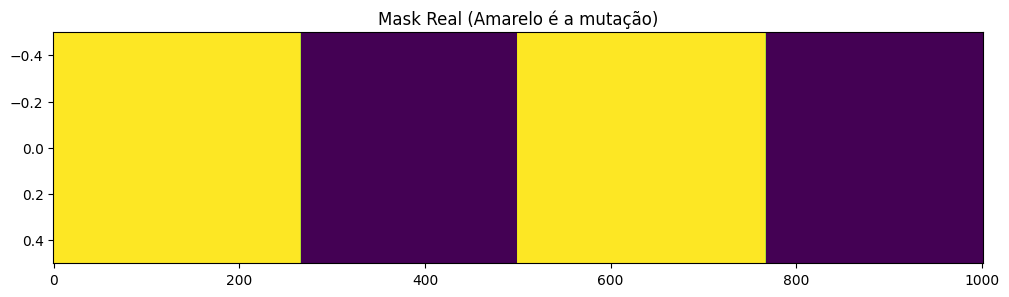

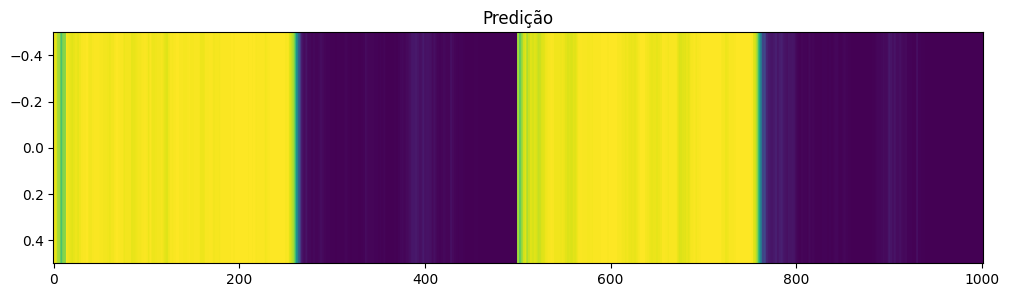

In [15]:

sample = 16

plt.figure(figsize=(12,3))
plt.imshow(y_test[sample].reshape(-1, 1002), aspect='auto')
plt.title("Mask Real (Amarelo é a mutação)")
plt.show()

plt.figure(figsize=(12,3))
plt.imshow(pred_mask[sample].reshape(-1, 1002), aspect='auto')
plt.title("Predição")
plt.show()

In [25]:
loss_bce = tf.keras.losses.BinaryCrossentropy()

test_loss = loss_bce(y_test, pred_mask)

print("Test BCE:", float(test_loss))

Test BCE: 0.3387685716152191


In [ ]:
loss_dice = tf.keras.losses.Dice()

test_loss = loss_dice(y_test, pred_mask)

print("Test Dice Loss:", float(test_loss))

Test Dice Loss: 0.3339031934738159


In [31]:
loss_IoU = tf.keras.metrics.IoU(num_classes=2, target_class_ids=[0])

test_loss = loss_IoU(y_test, pred_mask)

print("Test IoU Loss:", float(test_loss))

Test IoU Loss: 0.6812743544578552


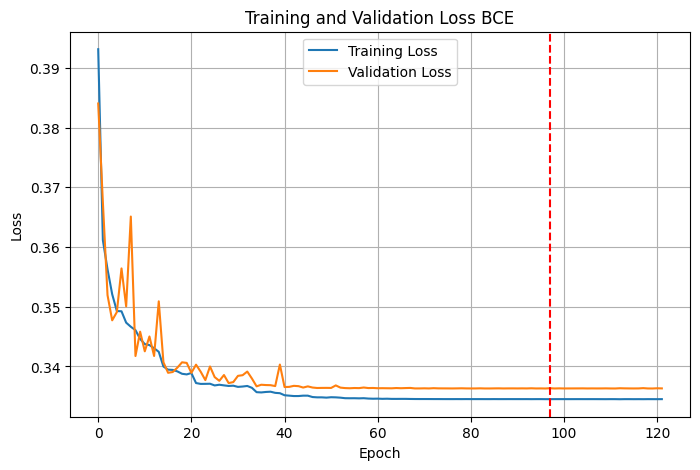

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')


plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss BCE')
plt.legend()
plt.grid(True)
plt.axvline(x=97, color='red', linestyle='--', linewidth=1.5)

plt.savefig(path + "\\loss_curve_BCE.pdf", format="pdf", bbox_inches="tight")
plt.savefig(path + "\\loss_curve_BCE.png", dpi=600, bbox_inches="tight")

plt.show()